In [69]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/

/Users/arikreuter/Documents/PhD/CausalPriorFitting


In [71]:
import sys
import os
import yaml
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from priordata_processing.Datasets.InterventionalDataset import InterventionalDataset
from src.models.GraphConditionedInterventionalPFN_sklearn import GraphConditionedInterventionalPFNSklearn


In [72]:
def plot_data(T, Y, X):
    data = pd.DataFrame(torch.cat([T, Y, X], dim = 1).numpy(), columns = ['T', 'Y'] + [f'{i}' for i in range(X.shape[1])])
    sns.pairplot(data=data)
    plt.title('Scatter plot of T vs Y colored by X')
    plt.show()

def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2

## Load Configuration

In [73]:
# Load the config file
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16677927.0/step_50000_config_927.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16677927.0/step_50000_927.pt"



with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Config loaded successfully!")
print(f"Experiment: {config['experiment_name']}")
print(f"Mode: {config['mode']}")

Config loaded successfully!
Experiment: two_nodes_lingaus_hard_attention_only
Mode: interventional


## Extract Configurations

In [74]:
# Extract the three main configs needed for the dataset
scm_config = config['scm_config']
dataset_config = config['dataset_config']
preprocessing_config = config['preprocessing_config']

print("SCM Config keys:", list(scm_config.keys()))
print("Dataset Config keys:", list(dataset_config.keys()))
print("Preprocessing Config keys:", list(preprocessing_config.keys()))

SCM Config keys: ['num_nodes', 'graph_edge_prob', 'graph_seed', 'xgboost_prob', 'mechanism_seed', 'mlp_nonlins', 'mlp_num_hidden_layers', 'mlp_hidden_dim', 'mlp_activation_mode', 'mlp_use_batch_norm', 'xgb_node_shape', 'xgb_num_hidden_layers', 'xgb_hidden_dim', 'xgb_activation_mode', 'xgb_use_batch_norm', 'xgb_n_training_samples', 'xgb_add_noise', 'random_additive_std', 'exo_std_distribution', 'endo_std_distribution', 'exo_std_mean', 'exo_std_std', 'endo_std_mean', 'endo_std_std', 'endo_p_zero', 'noise_mixture_proportions', 'use_exogenous_mechanisms', 'mechanism_generator_seed']
Dataset Config keys: ['dataset_size', 'max_number_samples_per_dataset', 'max_number_train_samples_per_dataset', 'max_number_test_samples_per_dataset', 'n_test_samples_per_dataset', 'return_adjacency_matrix', 'min_target_variance', 'max_resample_attempts', 'max_number_features', 'seed']
Preprocessing Config keys: ['dropout_prob', 'shuffle_data', 'target_feature', 'feature_standardize', 'feature_negative_one_one_

In [75]:
# load model


graphintpfn = GraphConditionedInterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    verbose=True,  # Enable verbose mode to see diagnostic messages
)
graphintpfn.load()


[GraphConditionedInterventionalPFNSklearn] Loading model...
  Config: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16677927.0/step_50000_config_927.yaml
  Checkpoint: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16677927.0/step_50000_927.pt
  BarDistribution enabled: 1000 bars, output_dim=1004
  Graph conditioning mode: ultimate_hard_attention_only
  Building model with 2 features...
  Creating UltimateGraphConditionedInterventionalPFN
    use_attention_masking: True
    use_gcn: False
    use_adaln: False
    use_soft_attention_bias: False
  Loading checkpoint from /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16677927.0/step_50000_927.pt...
  BarDistribution state loaded from checkpoint
    centers shape: torch.Size([1000])
    edges shape: torch.Size([1001])
  Checkpoint loaded successfully
  Model loaded with

## Two-Node case

In [76]:
# Override dataset size to make it smaller for exploration
dataset_config_twonode = dataset_config.copy()
dataset_config_twonode['return_adjacency_matrix'] = {'value': True}  # Enable adjacency matrix

scm_config_twonode = scm_config.copy()
scm_config_twonode['num_nodes'] = {'value': 2}
scm_config_twonode['graph_edge_prob'] = {'value': 0.5}
scm_config_twonode["exo_std_mean"] = {"value": 1.0}
scm_config_twonode["exo_std_std"] = {"value": 1e-10}

scm_config_twonode["endo_std_mean"] = {"value": 0.3}
scm_config_twonode["endo_std_std"] = {"value": 1e-10}

In [77]:

# Create dataset with debugging enabled
dataset = InterventionalDataset(
    scm_config=scm_config_twonode,
    preprocessing_config=preprocessing_config,
    dataset_config=dataset_config_twonode,
    seed=42,
    return_scm=True  # This returns (data, adjacency, scm, processor, intervention_node)
)

print(f"Dataset created with {len(dataset)} samples")

Dataset created with 100000000 samples


0 1 []


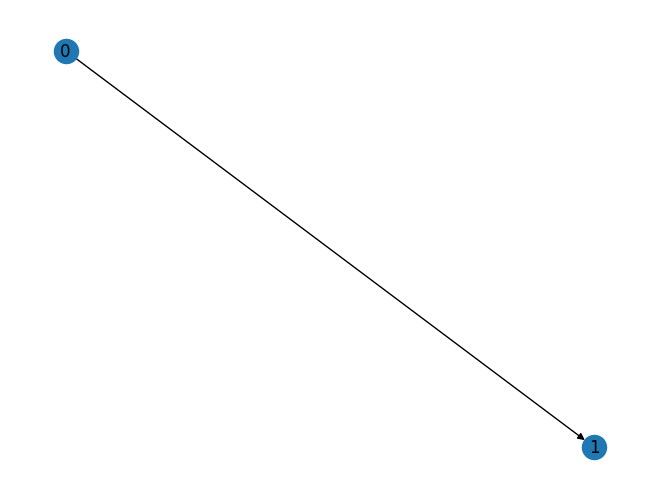

Observational Data:


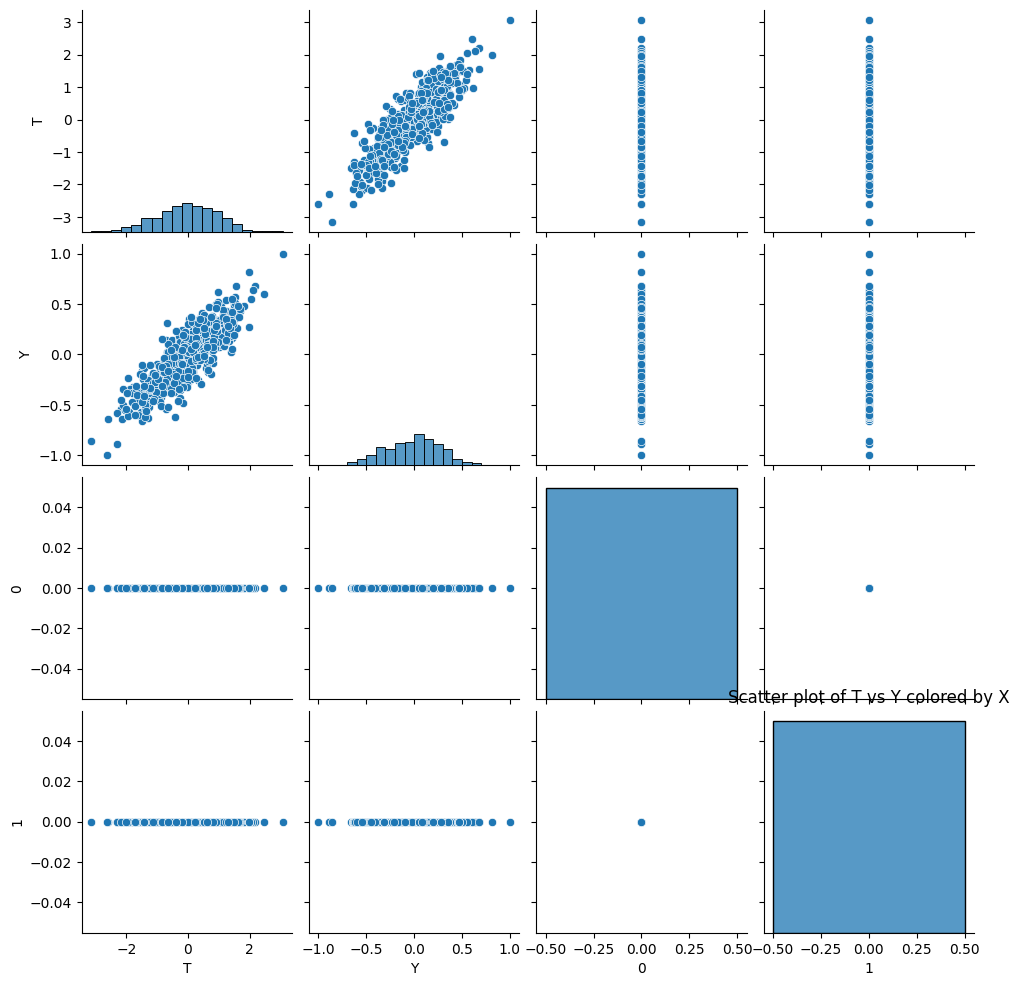

Interventional Data:


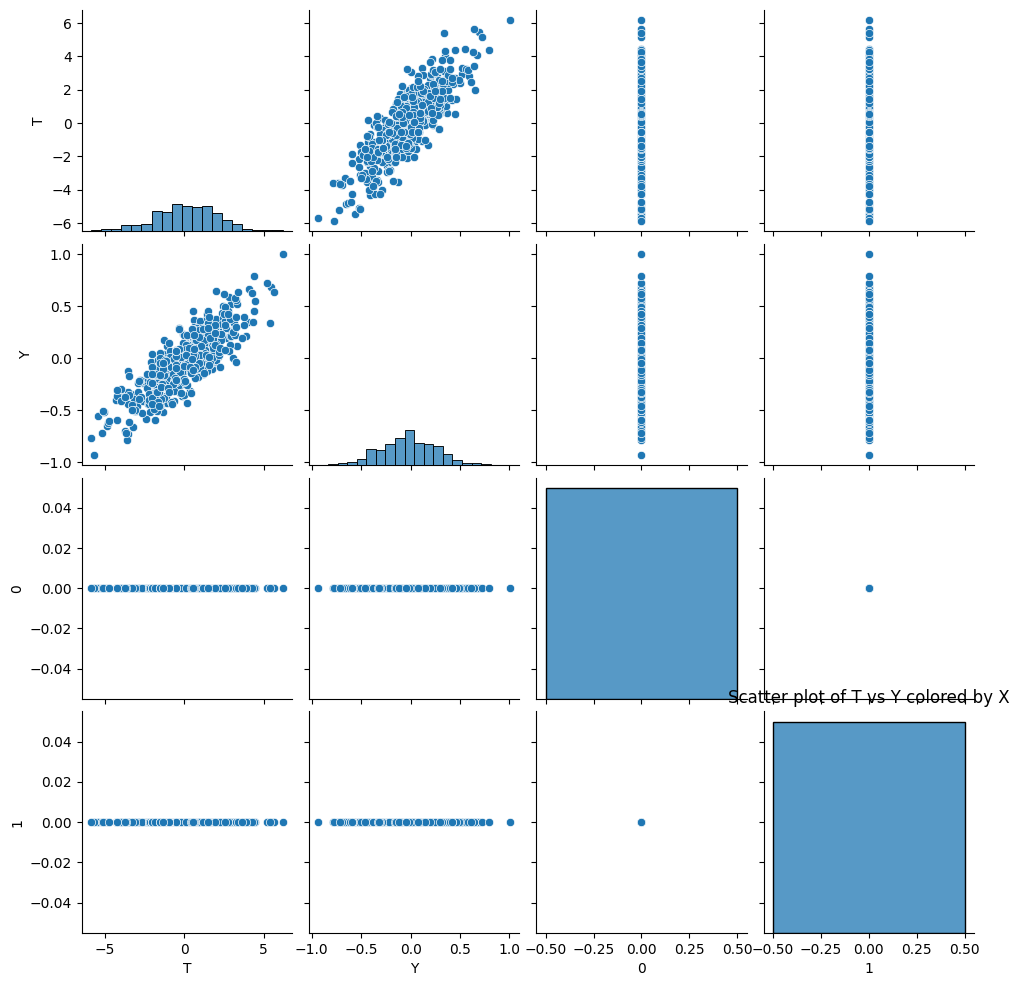

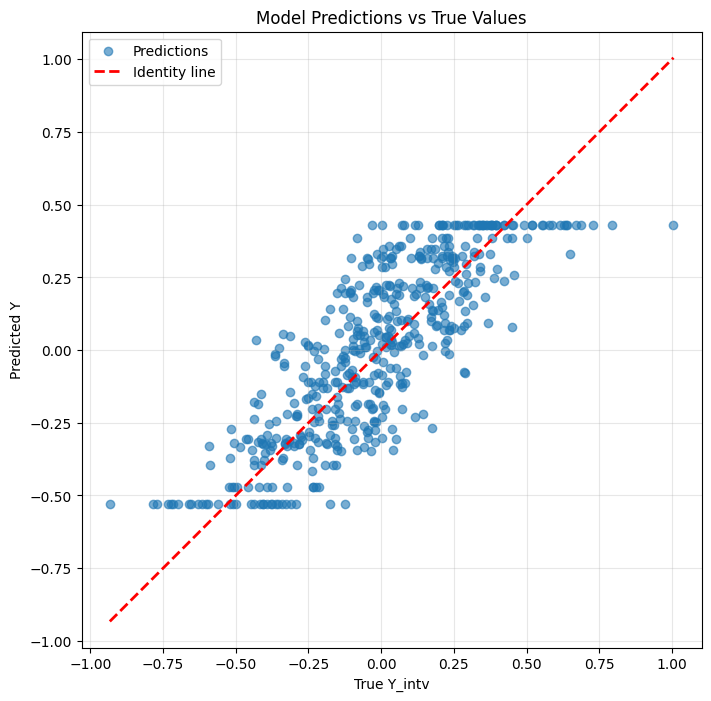

Model MSE on interventional data: 0.16986459493637085
Model R2 on interventional data: -1026.299560546875
NLL on interventional datra: -0.2840867340564728


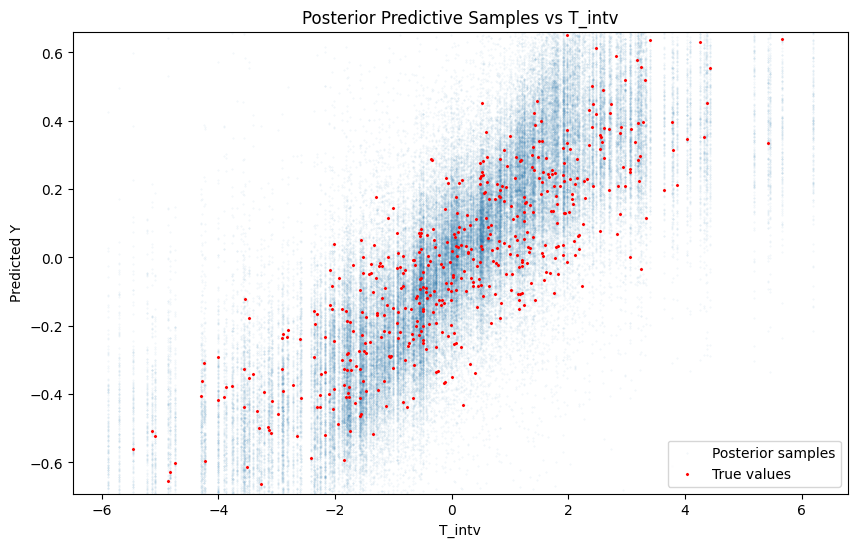

In [78]:
# T -> Y

X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, intervention_node = dataset[2]  # Access the first sample to trigger data generation
print(processor.intervened_feature, processor.selected_target_feature, processor.kept_feature_indices)
scm.dag.draw()  # Visualize the SCM DAG
print("Observational Data:")
plot_data(T_obs, Y_obs, X_obs)  # Plot observational data
print("Interventional Data:")
plot_data(T_intv, Y_intv, X_intv)  # Plot interventional

model_pred = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
)

# predictions versus true
plt.figure(figsize=(8, 8))
plt.scatter(Y_intv.numpy(), model_pred, alpha=0.6, label='Predictions')
# Add identity line
min_val = min(Y_intv.numpy().min(), model_pred.min())
max_val = max(Y_intv.numpy().max(), model_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity line')
plt.xlabel('True Y_intv')
plt.ylabel('Predicted Y')
plt.title('Model Predictions vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

model_mse = torch.mean((torch.tensor(model_pred) - Y_intv) ** 2).item()
print(f"Model MSE on interventional data: {model_mse}")

model_r2 = r2_score(Y_intv, torch.tensor(model_pred)).item()
print(f"Model R2 on interventional data: {model_r2}")

nll = - np.mean(graphintpfn.predict_log_likelihood(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    Y_intv=Y_intv.numpy(),
    adjacency_matrix=adj.numpy(),
))

print(f"NLL on interventional datra: {nll}")

pred_samples = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
    prediction_type='sample',
    num_samples=200
)

# plot samples versus T_intv
# pred_samples has shape (num_samples, n_points)
# We need to repeat T_intv for each sample
num_samples = pred_samples.shape[0]
T_intv_repeated = torch.tile(T_intv, (num_samples, 1)).flatten()
pred_samples_flat = pred_samples.flatten()

# Calculate quantiles for y-axis limits
y_min = torch.quantile(torch.tensor(pred_samples_flat), 0.025).item()
y_max = torch.quantile(torch.tensor(pred_samples_flat), 0.975).item()

plt.figure(figsize=(10, 6))
plt.scatter(T_intv_repeated.numpy(), pred_samples_flat, alpha=0.1, s=0.1, label='Posterior samples')
plt.scatter(T_intv.numpy(), Y_intv.numpy(), color='red', s=1, marker='x', label='True values', linewidths=2)
plt.xlabel('T_intv')
plt.ylabel('Predicted Y')
plt.title('Posterior Predictive Samples vs T_intv')
plt.ylim(y_min, y_max)
plt.legend()
plt.show()


0 1 []


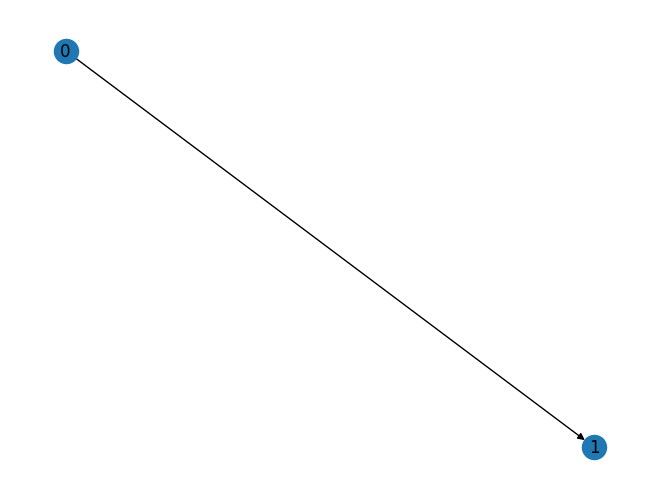

Observational Data:


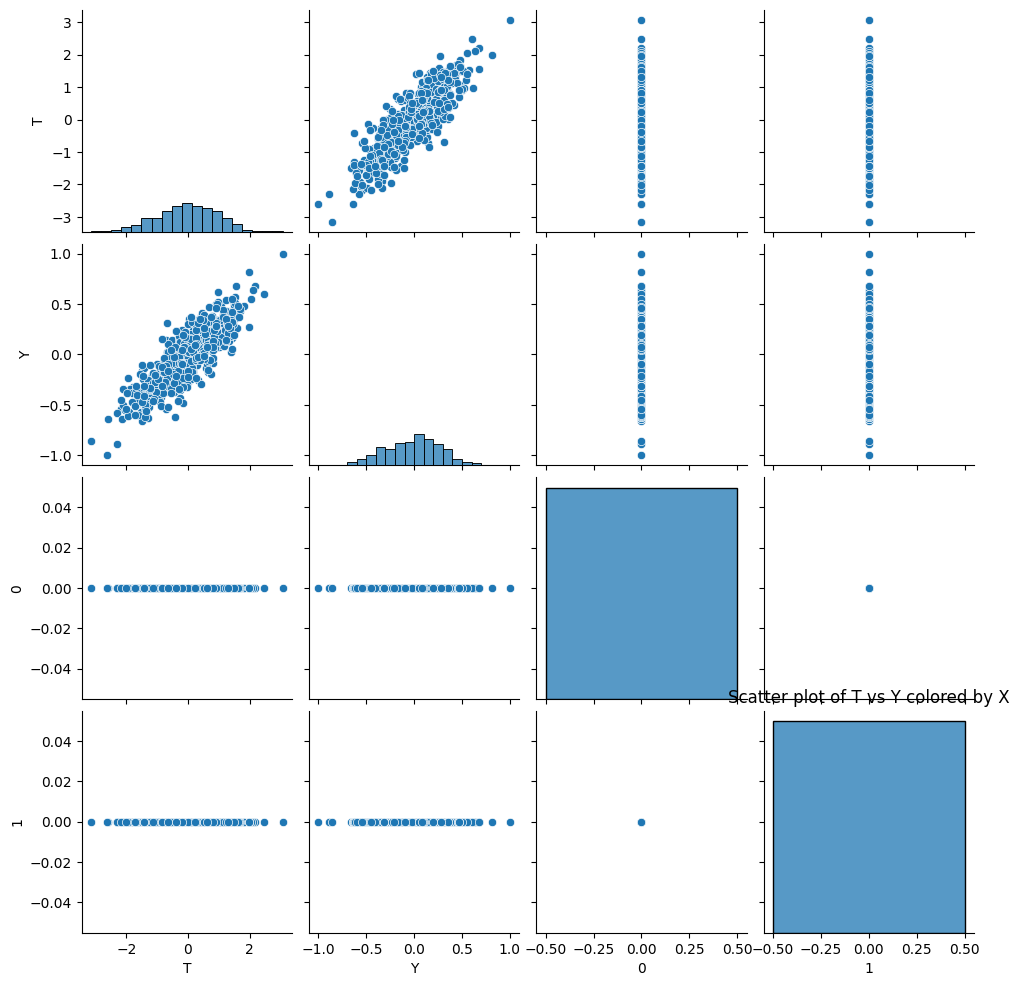

Interventional Data:


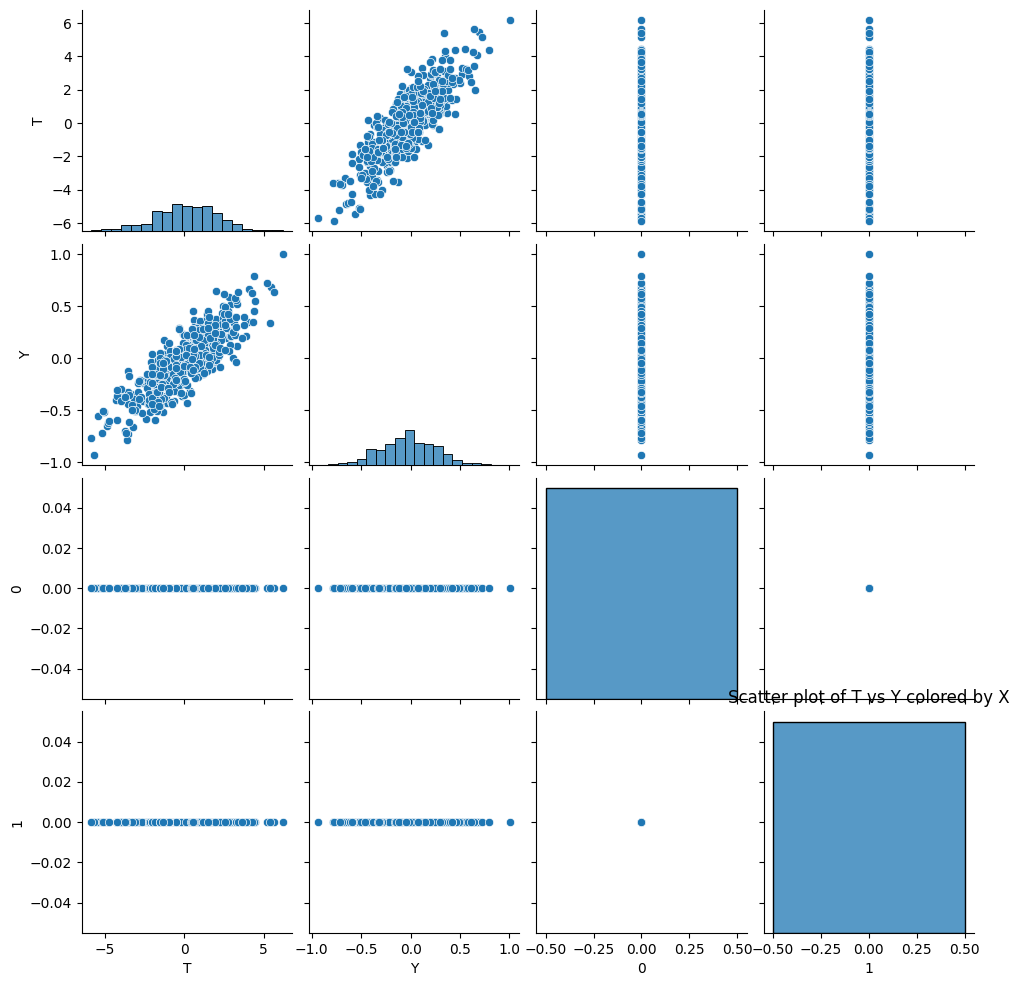

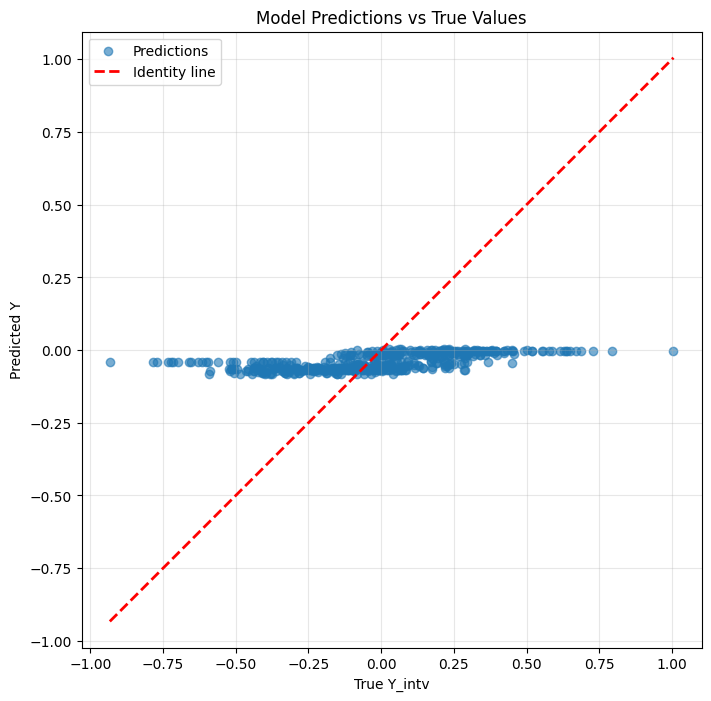

Model MSE on interventional data: 0.08372842520475388
Model R2 on interventional data: -505.36907958984375
NLL on interventional datra: 0.1353393793106079


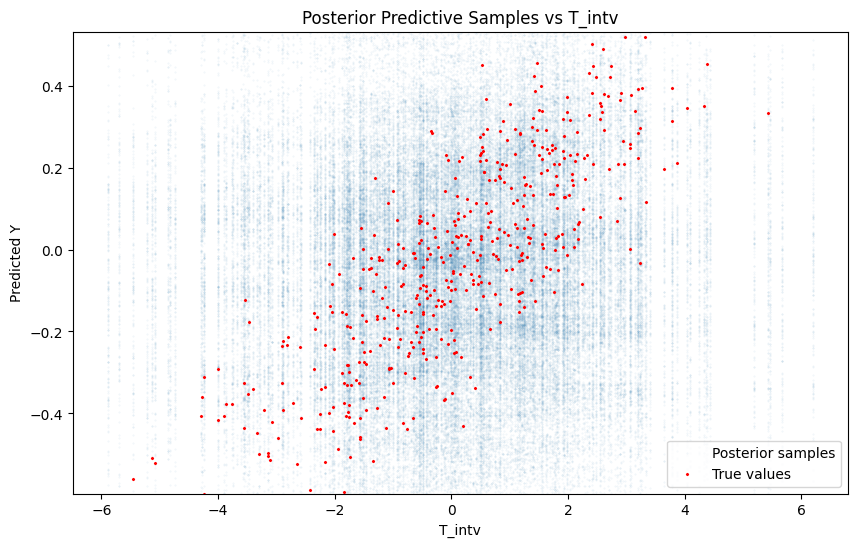

In [79]:
# T -> Y, but with reverse adjacency mat

X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, intervention_node = dataset[2]  # Access the first sample to trigger data generation
adj = adj.T
print(processor.intervened_feature, processor.selected_target_feature, processor.kept_feature_indices)
scm.dag.draw()  # Visualize the SCM DAG
print("Observational Data:")
plot_data(T_obs, Y_obs, X_obs)  # Plot observational data
print("Interventional Data:")
plot_data(T_intv, Y_intv, X_intv)  # Plot interventional

model_pred = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
)

# predictions versus true
plt.figure(figsize=(8, 8))
plt.scatter(Y_intv.numpy(), model_pred, alpha=0.6, label='Predictions')
# Add identity line
min_val = min(Y_intv.numpy().min(), model_pred.min())
max_val = max(Y_intv.numpy().max(), model_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity line')
plt.xlabel('True Y_intv')
plt.ylabel('Predicted Y')
plt.title('Model Predictions vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

model_mse = torch.mean((torch.tensor(model_pred) - Y_intv) ** 2).item()
print(f"Model MSE on interventional data: {model_mse}")

model_r2 = r2_score(Y_intv, torch.tensor(model_pred)).item()
print(f"Model R2 on interventional data: {model_r2}")

nll = - np.mean(graphintpfn.predict_log_likelihood(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    Y_intv=Y_intv.numpy(),
    adjacency_matrix=adj.numpy(),
))

print(f"NLL on interventional datra: {nll}")

pred_samples = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
    prediction_type='sample',
    num_samples=200
)

# plot samples versus T_intv
# pred_samples has shape (num_samples, n_points)
# We need to repeat T_intv for each sample
num_samples = pred_samples.shape[0]
T_intv_repeated = torch.tile(T_intv, (num_samples, 1)).flatten()
pred_samples_flat = pred_samples.flatten()

# Calculate quantiles for y-axis limits
y_min = torch.quantile(torch.tensor(pred_samples_flat), 0.025).item()
y_max = torch.quantile(torch.tensor(pred_samples_flat), 0.975).item()

plt.figure(figsize=(10, 6))
plt.scatter(T_intv_repeated.numpy(), pred_samples_flat, alpha=0.1, s=0.1, label='Posterior samples')
plt.scatter(T_intv.numpy(), Y_intv.numpy(), color='red', s=1, marker='x', label='True values', linewidths=2)
plt.xlabel('T_intv')
plt.ylabel('Predicted Y')
plt.title('Posterior Predictive Samples vs T_intv')
plt.ylim(y_min, y_max)
plt.legend()
plt.show()


1 0 []


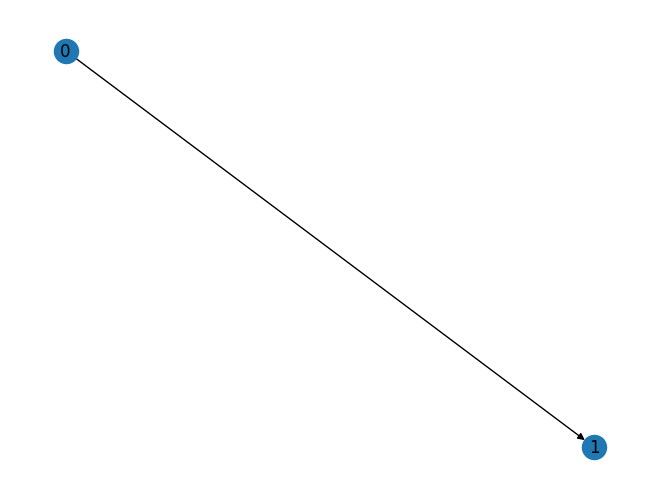

Observational Data:


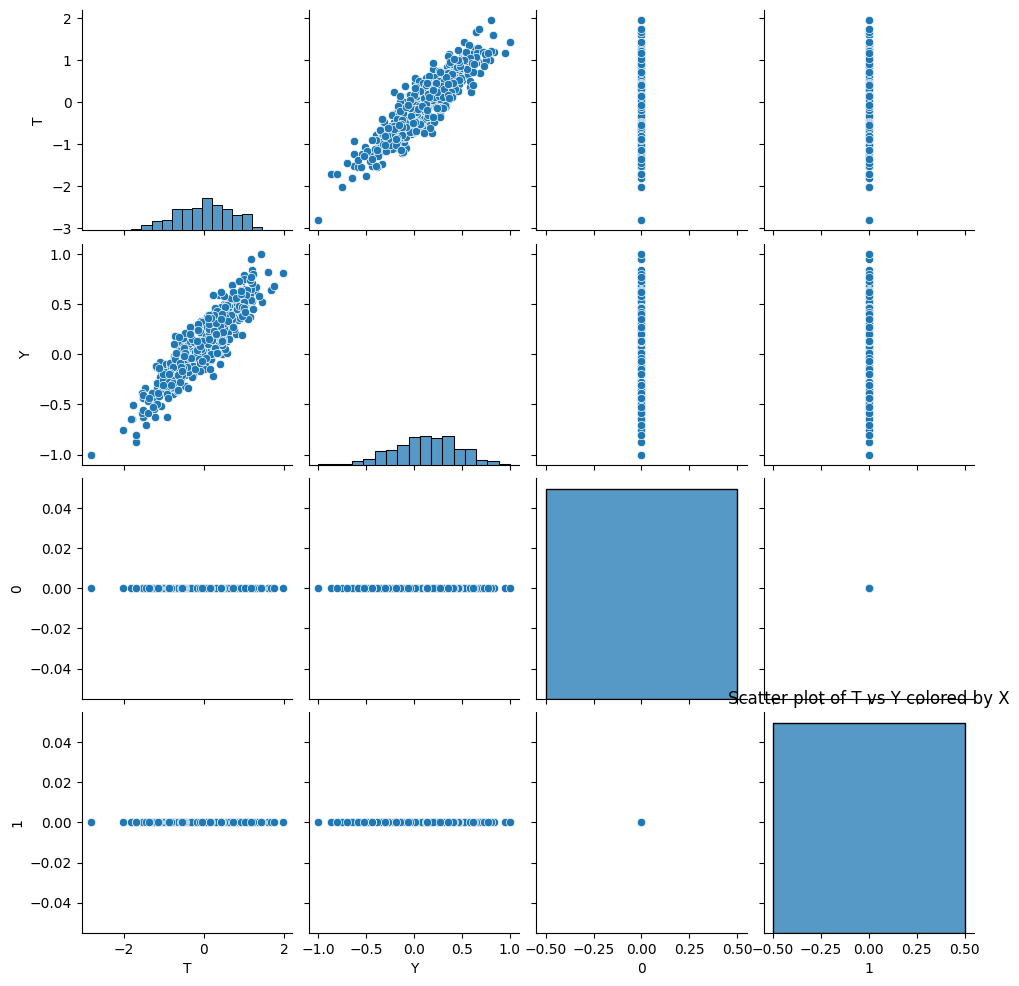

Interventional Data:


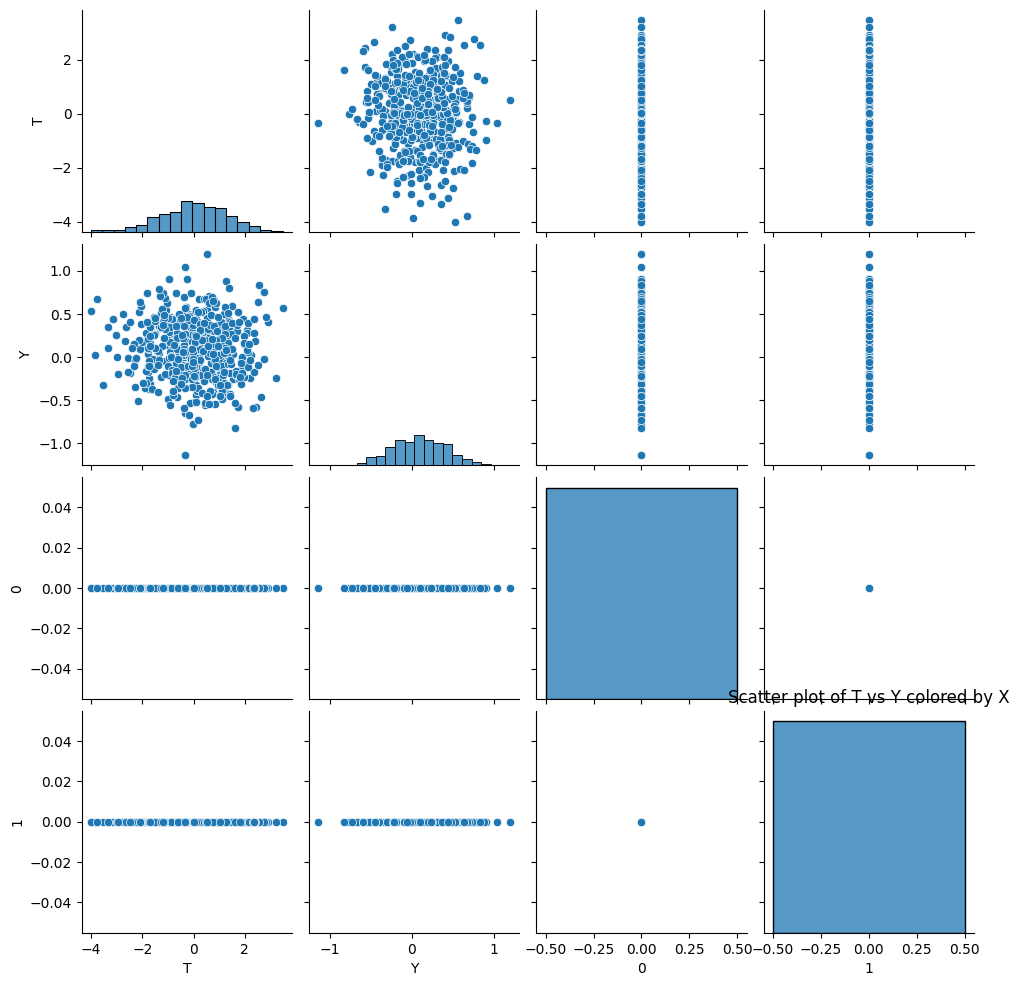

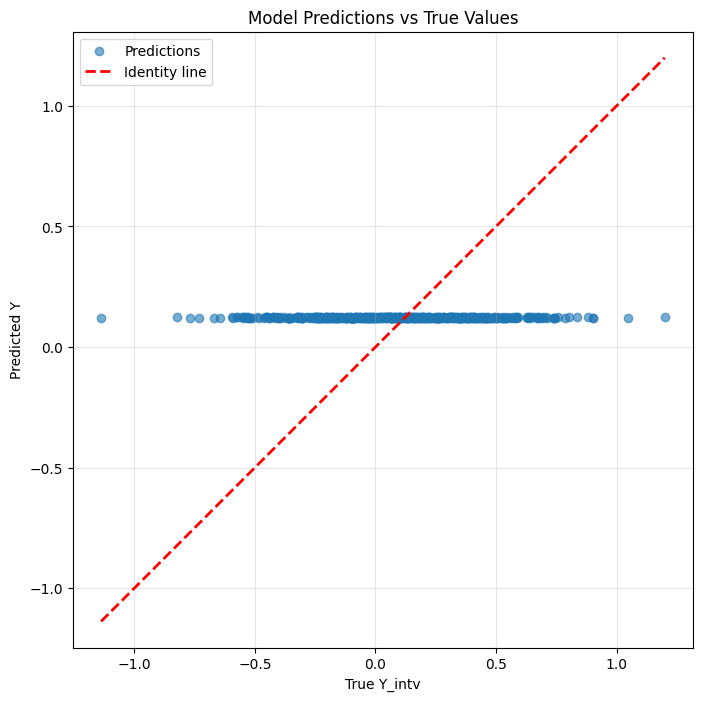

Model MSE on interventional data: 0.11272469162940979
Model R2 on interventional data: -502.9802551269531
NLL on interventional datra: 0.3250502645969391


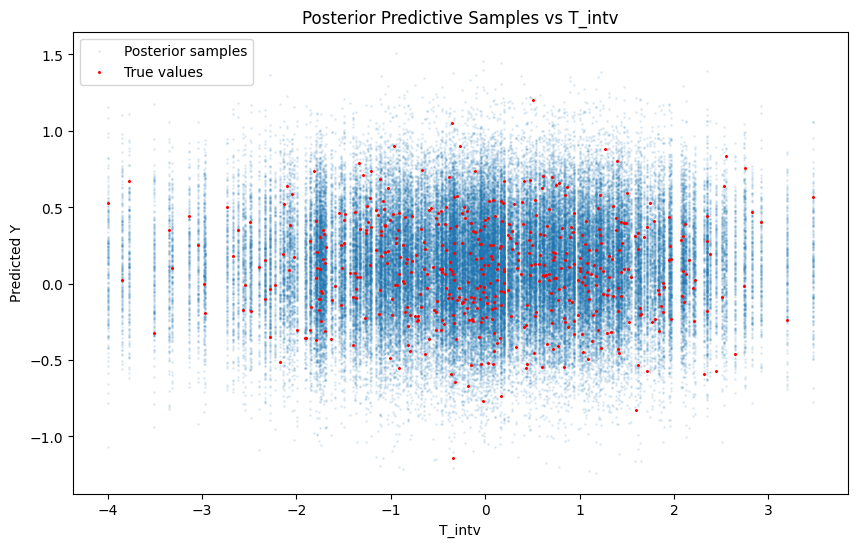

In [82]:
# Y -> T

X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, intervention_node = dataset[20]  # Access the first sample to trigger data generation, 16
print(processor.intervened_feature, processor.selected_target_feature, processor.kept_feature_indices)
scm.dag.draw()  # Visualize the SCM DAG
print("Observational Data:")
plot_data(T_obs, Y_obs, X_obs)  # Plot observational data
print("Interventional Data:")
plot_data(T_intv, Y_intv, X_intv)  # Plot interventional

model_pred = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
)

# predictions versus true
plt.figure(figsize=(8, 8))
plt.scatter(Y_intv.numpy(), model_pred, alpha=0.6, label='Predictions')
# Add identity line
min_val = min(Y_intv.numpy().min(), model_pred.min())
max_val = max(Y_intv.numpy().max(), model_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity line')
plt.xlabel('True Y_intv')
plt.ylabel('Predicted Y')
plt.title('Model Predictions vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

model_mse = torch.mean((torch.tensor(model_pred) - Y_intv) ** 2).item()
print(f"Model MSE on interventional data: {model_mse}")

model_r2 = r2_score(Y_intv, torch.tensor(model_pred)).item()
print(f"Model R2 on interventional data: {model_r2}")

nll = - np.mean(graphintpfn.predict_log_likelihood(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    Y_intv=Y_intv.numpy(),
    adjacency_matrix=adj.numpy(),
))

print(f"NLL on interventional datra: {nll}")

pred_samples = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
    prediction_type='sample',
    num_samples=200
)

# plot samples versus T_intv
# pred_samples has shape (num_samples, n_points)
# We need to repeat T_intv for each sample
num_samples = pred_samples.shape[0]
T_intv_repeated = torch.tile(T_intv, (num_samples, 1)).flatten()
pred_samples_flat = pred_samples.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(T_intv_repeated.numpy(), pred_samples_flat, alpha=0.1, s=1, label='Posterior samples')
plt.scatter(T_intv.numpy(), Y_intv.numpy(), color='red', s=1, marker='x', label='True values', linewidths=2)
plt.xlabel('T_intv')
plt.ylabel('Predicted Y')
plt.title('Posterior Predictive Samples vs T_intv')
plt.legend()
plt.show()

0 1 []


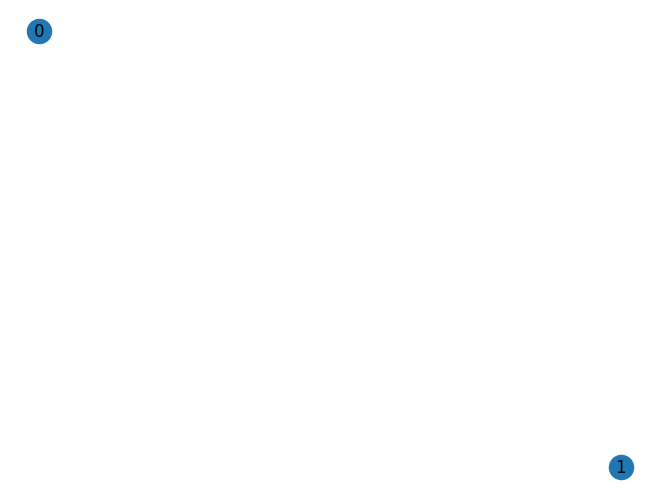

Observational Data:


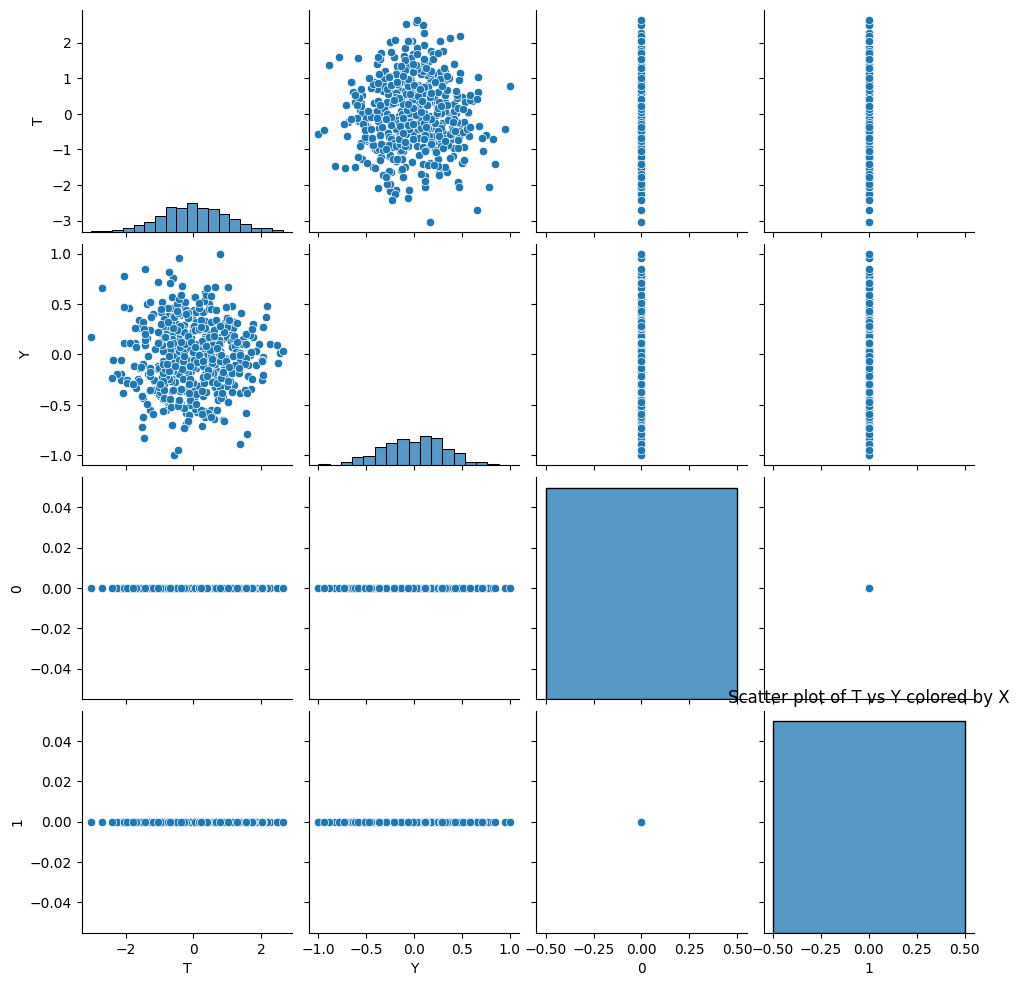

Interventional Data:


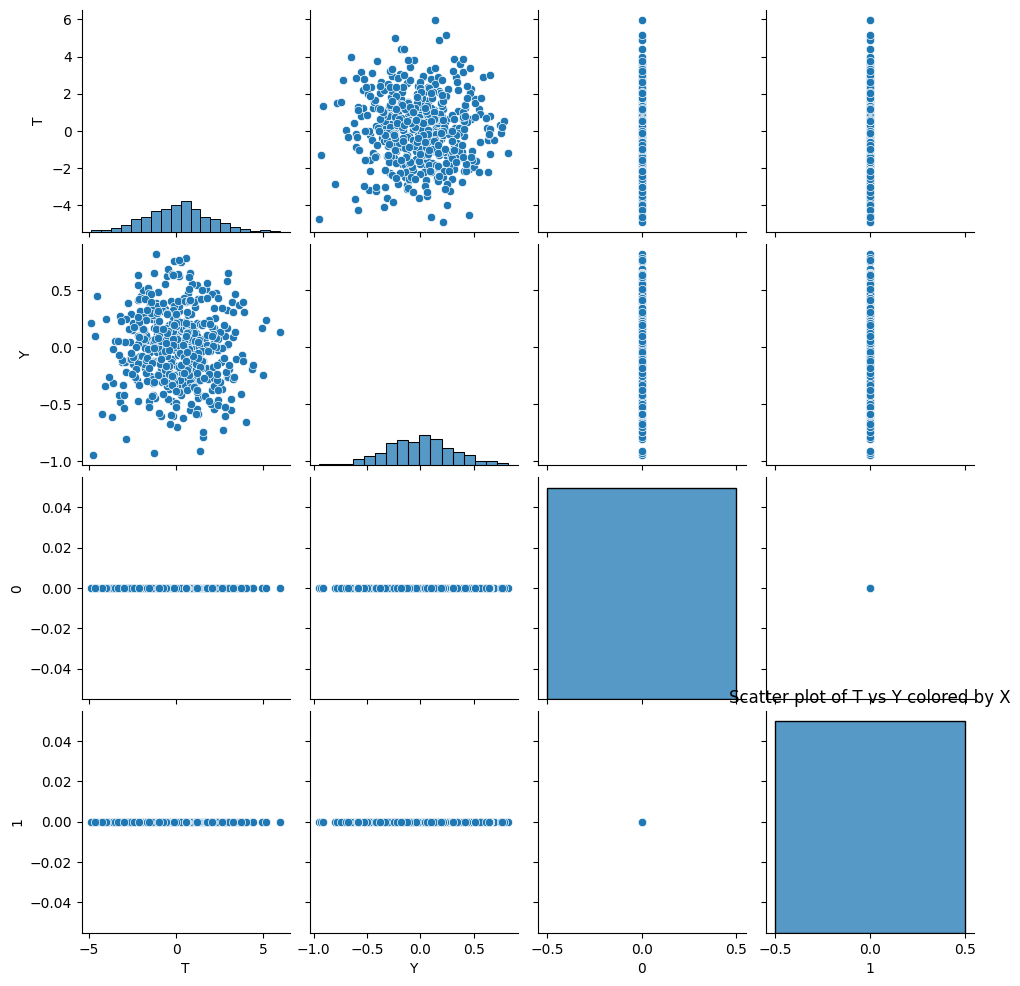

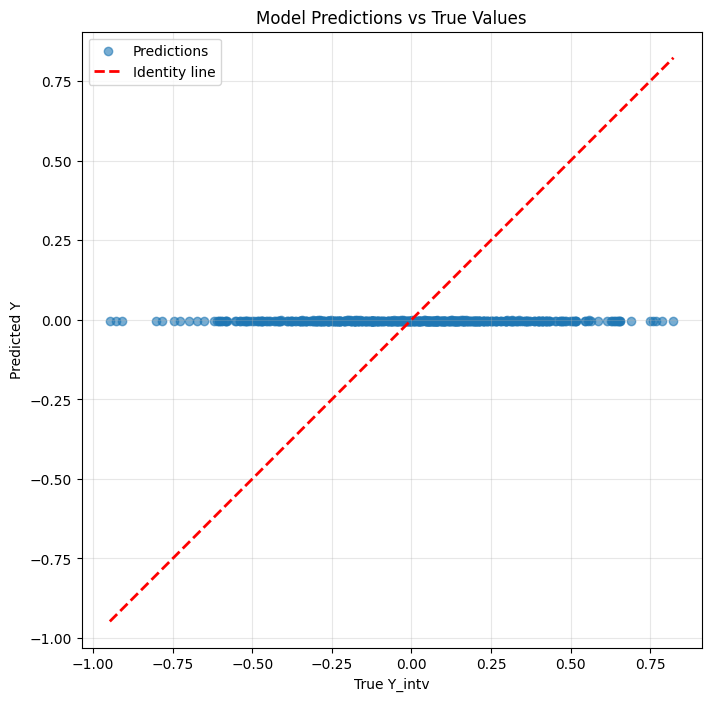

Model MSE on interventional data: 0.09908195585012436
Model R2 on interventional data: -499.0234069824219
NLL on interventional datra: 0.2654624581336975
NLL on interventional datra: 0.2654624581336975


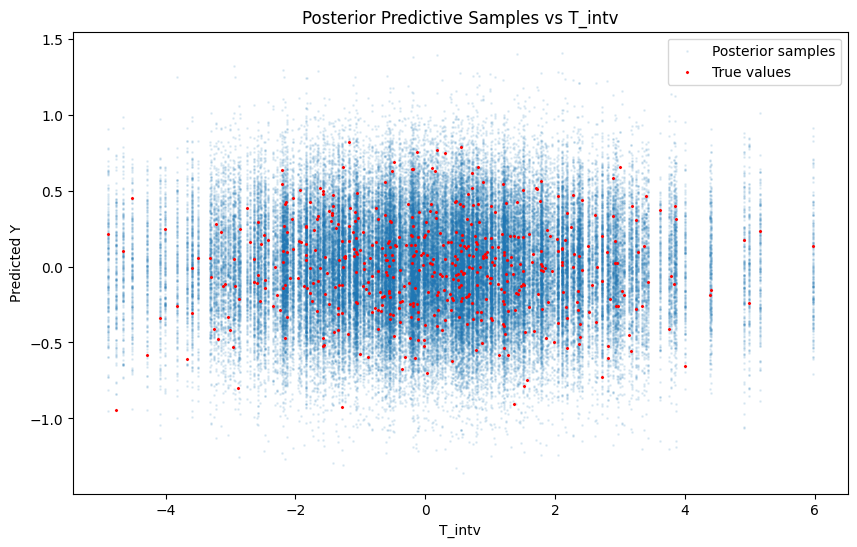

In [83]:
# Independent

X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, intervention_node = dataset[0]  # Access the first sample to trigger data generation
print(processor.intervened_feature, processor.selected_target_feature, processor.kept_feature_indices)
scm.dag.draw()  # Visualize the SCM DAG
print("Observational Data:")
plot_data(T_obs, Y_obs, X_obs)  # Plot observational data
print("Interventional Data:")
plot_data(T_intv, Y_intv, X_intv)  # Plot interventional

model_pred = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
)

# predictions versus true
plt.figure(figsize=(8, 8))
plt.scatter(Y_intv.numpy(), model_pred, alpha=0.6, label='Predictions')
# Add identity line
min_val = min(Y_intv.numpy().min(), model_pred.min())
max_val = max(Y_intv.numpy().max(), model_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity line')
plt.xlabel('True Y_intv')
plt.ylabel('Predicted Y')
plt.title('Model Predictions vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

model_mse = torch.mean((torch.tensor(model_pred) - Y_intv) ** 2).item()
print(f"Model MSE on interventional data: {model_mse}")

model_r2 = r2_score(Y_intv, torch.tensor(model_pred)).item()
print(f"Model R2 on interventional data: {model_r2}")

pred_samples = graphintpfn.predict(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    adjacency_matrix=adj.numpy(),
    prediction_type='sample',
    num_samples=200
)

nll = - np.mean(graphintpfn.predict_log_likelihood(
    X_obs=X_obs.numpy(),
    T_obs=T_obs.numpy(),
    Y_obs=Y_obs.numpy(),
    X_intv=X_intv.numpy(),
    T_intv=T_intv.numpy(),
    Y_intv=Y_intv.numpy(),
    adjacency_matrix=adj.numpy(),
))

print(f"NLL on interventional datra: {nll}")

# plot samples versus T_intv
# pred_samples has shape (num_samples, n_points)
# We need to repeat T_intv for each sample
num_samples = pred_samples.shape[0]
T_intv_repeated = torch.tile(T_intv, (num_samples, 1)).flatten()
pred_samples_flat = pred_samples.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(T_intv_repeated.numpy(), pred_samples_flat, alpha=0.1, s=1, label='Posterior samples')
plt.scatter(T_intv.numpy(), Y_intv.numpy(), color='red', s=1, marker='x', label='True values', linewidths=2)
plt.xlabel('T_intv')
plt.ylabel('Predicted Y')
plt.title('Posterior Predictive Samples vs T_intv')
plt.legend()
plt.show()